In [1]:
import torch
import os
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
import mmtrack.pre_process_mm as pre
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks, write_to_geff
from trackastra.data import example_data_bacteria
import tifffile
import napari
import json
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
from mmtrack import plot_cells

pyclesperanto_prototype not installed - using CPU (scipy)


/opt/miniconda3/envs/trackastra/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def stack_to_kymograph(stack):
    """
    takes a numpyarray of an image in the format (t, y, x) and converts it into a kymograph
    """

    kymograph_gray = []
    for i in range(stack.shape[0]):
        frame = stack[i]
        if frame.ndim == 3:
            kymograph_gray.append(frame, axis=2)
        else:
            kymograph_gray.append(frame)
    
    kymograph = np.concatenate(kymograph_gray, axis =1)
    return kymograph

In [3]:
# code needed to help trim tif stacks
def get_tiff_frame_count(file_path):
	"""
	Reads a TIFF file using imread and returns the index of the last time frame (T - 1).
	NOTE: This loads the entire file into memory.
	"""
	try:
		# Load the entire image stack into memory
		img_stack = tifffile.imread(file_path)

		shape = img_stack.shape

		# Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1
			return shape[0] - 1
		else:
			# Single 2D image
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph):
    t, y, x = imgs.shape
    
    # Transpose to (y, t, x) then reshape to (y, t*x)
    kymo_imgs = imgs.transpose(1, 0, 2).reshape(y, -1)  # (400, 540)
    kymo_masks = ctc_masks.transpose(1, 0, 2).reshape(y, -1)

    kymo_tracks = napari_tracks.copy()
    # New x position: time_frame * width + original_x
    new_x = napari_tracks[:, 1] * x + napari_tracks[:, 3]
    kymo_tracks = np.column_stack([
        napari_tracks[:, 0],  # track_id
        np.zeros(len(napari_tracks)),  # dummy time (all in same frame)
        napari_tracks[:, 2],  # y stays the same
        new_x  # new x position
    ])

    v = napari.Viewer()
    v.add_image(kymo_imgs, name='kymograph')
    v.add_labels(kymo_masks, name='masks_kymo')
    v.add_tracks(data=kymo_tracks, graph=napari_tracks_graph, name='tracks_kymo')

def trim_stacks(time_dict, base_path):
    base_path =f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing'

    time_range_dict = json.loads(time_dict)
    # print(len(time_range_dict))
    phase_c_str = '0'
    fluor_c_str = '1'

    for folder, fov_dict in time_range_dict.items():    
        for fov_id in fov_dict.keys():
            trench_time_ranges = fov_dict[fov_id]
            print(f"  FOV: {fov_id}, Trenches: {list(trench_time_ranges.keys())}")

            for peak_id, time_info in trench_time_ranges.items():
                base_file_path = os.path.join(base_path, folder, 'hyperstacked', 'drift_corrected', 'rotated',
                                                'mm_channels', 'subtracted')
                path_to_phase_stack = os.path.join(base_file_path,
                                                    f'subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_c_str}.tif')
                path_to_labeled_stack = os.path.join(base_file_path,
                                                        f'mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_c_str}.tif')
                path_to_fluor_stack = os.path.join(base_file_path,
                                                    f'subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_c_str}.tif')
                # --- Dynamic Time Range Assignment ---
                start = time_info['start']
                end = time_info.get('end') 
            
                if end is None:
                    # Calculate end frame dynamically using the Phase stack file
                    end = get_tiff_frame_count(path_to_phase_stack)
                    if end == 0:
                        print(f"    WARNING: Could not determine frame count for {peak_id}. Skipping.")
                        continue

                # 2. Read Image Stacks
                try:
                    stack_phase = tifffile.imread(path_to_phase_stack)
                    stack_labeled = tifffile.imread(path_to_labeled_stack)
                    stack_fluor = tifffile.imread(path_to_fluor_stack)
                except FileNotFoundError as e:
                    print(f"    WARNING: Required file not found for {peak_id}: {e}. Skipping.")
                    continue
                # here is where I need to incorporate start and end
                print(start)
                print(end) 
                stack_phase_trimmed = stack_phase[start:end, :, :].copy()
                stack_labeled_trimmed = stack_labeled[start:end, :, :].copy()   
                return stack_phase_trimmed, stack_labeled_trimmed        

In [ ]:
# this code loads up all of our datasets, note that it is not needed for track_astra 
path_all_lineages_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/tracked_all_cell_data_aggregate_032626.pkl'
path_all_cell_data_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/all_cell_data_aggregate_032626.pkl'
all_lineages_df = pd.read_pickle(path_all_lineages_df)
all_cell_data_df = pd.read_pickle(path_all_cell_data_df)

# code to establish some trouble shooting. Experiment_name can be changed to trouble shoot different experiments 
experiment = 'DUMM_gitg068_baeS_100225'
base_path =f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
path_to_phase_stack_dir=f'{base_path}'
path_to_labels_stack_dir =f'{base_path}/mask_kymos'
phase_list = os.listdir(path_to_phase_stack_dir)
mask_list =os.listdir(path_to_labels_stack_dir)

In [ ]:
stack_phase_trimmed, stack_labeled_trimmed = trim_stacks(time_dict, base_path)

In [4]:
# load all data, note that path files may need to be updated
imgs = np.load('/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_imgs_020_589.npy')
napari_tracks = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_napari_tracks_020_589.npy")
ctc_masks = np.load("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_ctc_masks_020_589.npy")


with open("/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output/DUMM_giTG059_068_SC_093025_napari_tracks_graph_020_589.json") as f:
    napari_tracks_graph = json.load(f)
# (optional) convert keys/values back to int if needed:
napari_tracks_graph = {int(k): int(v) for k, v in napari_tracks_graph.items()}

In [15]:
plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph)

In [14]:
path_new_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/napari_corrections/20_589_corrected_2.tif'
path_old_mask = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_020_region_589_c_0.tif'
path_to_phase_stack = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG059_068_SC_093025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_020_region_589_c_0.tif'

In [15]:
phase_kymo = stack_to_kymograph(tifffile.imread(path_to_phase_stack))
mask_kymo_old=stack_to_kymograph(tifffile.imread(path_old_mask))
mask_kymo_new=stack_to_kymograph(tifffile.imread(path_new_mask))
tab20_cmap = plt.get_cmap("tab20")

In [16]:
colored_mask_old = np.zeros((*mask_kymo_old.shape, 4), dtype=np.float32)  
unique_labels = np.unique(mask_kymo_old)
for label in unique_labels:
    if label > 0: 
        mask_indices = (mask_kymo_old == label)
        colored_mask_old[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
        colored_mask_old[mask_indices, 3] = 1.0  

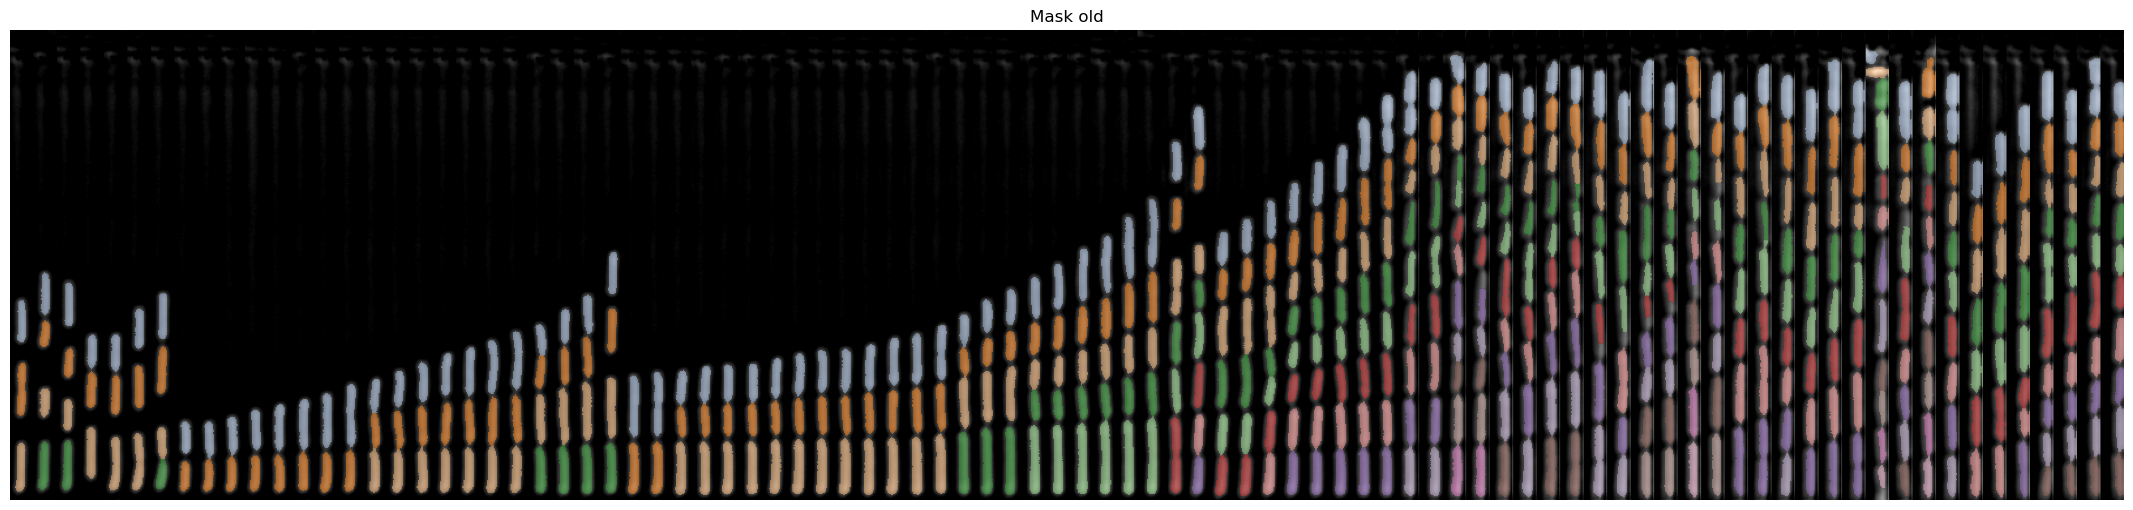

In [17]:
plt.figure(figsize=(60, 20))

plt.subplot(1, 2, 2)
plt.imshow(phase_kymo, cmap='gray')  
plt.imshow(colored_mask_old, alpha=0.5)  
plt.title(f'Mask old')
plt.axis('off')

plt.show()   

In [18]:
colored_mask_new = np.zeros((*mask_kymo_new.shape, 4), dtype=np.float32)  
unique_labels = np.unique(mask_kymo_new)
for label in unique_labels:
    if label > 0: 
        mask_indices = (mask_kymo_new == label)
        colored_mask_new[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
        colored_mask_new[mask_indices, 3] = 1.0 

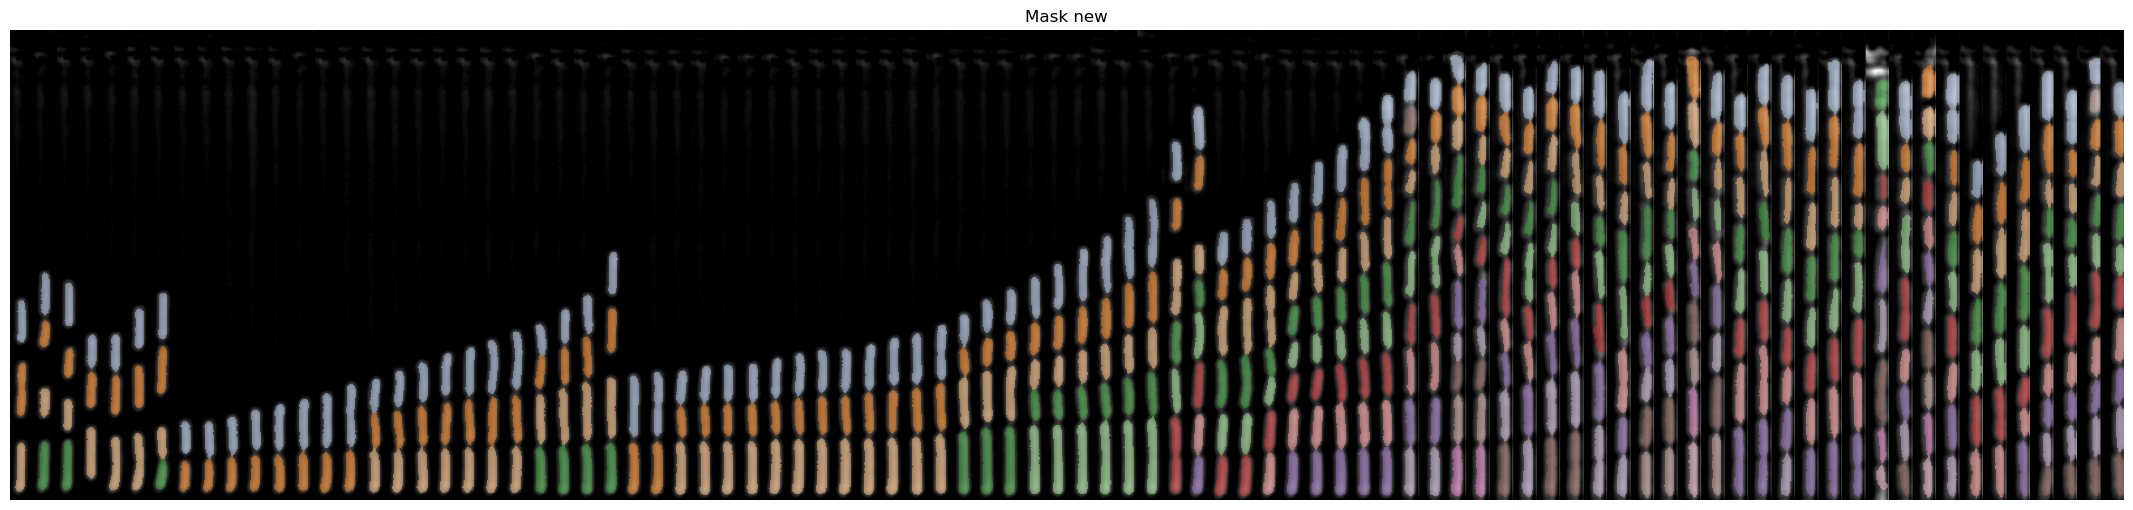

In [19]:
plt.figure(figsize=(60, 20))

plt.subplot(1, 2, 2)
plt.imshow(phase_kymo, cmap='gray')  
plt.imshow(colored_mask_new, alpha=0.5)  
plt.title(f'Mask new')
plt.axis('off')

plt.show()   

In [14]:
# Get all unique cell tracks
unique_tracks = np.unique(napari_tracks[:, 0])
print(f"Total number of cells tracked: {len(unique_tracks)}")

# For each cell track
for track_id in unique_tracks:
    # Get all timepoints for this cell
    cell_data = napari_tracks[napari_tracks[:, 0] == track_id]
    
    # Extract information
    timepoints = cell_data[:, 1]  # time
    y_coords = cell_data[:, 2]     # y position
    x_coords = cell_data[:, 3]     # x position
    
    print(f"Track {track_id}: {len(timepoints)} timepoints, "
          f"t={timepoints.min():.0f}-{timepoints.max():.0f}")

Total number of cells tracked: 70
Track 1.0: 1 timepoints, t=0-0
Track 2.0: 1 timepoints, t=79-79
Track 3.0: 3 timepoints, t=0-2
Track 4.0: 6 timepoints, t=1-6
Track 5.0: 6 timepoints, t=1-6
Track 6.0: 6 timepoints, t=0-5
Track 7.0: 44 timepoints, t=6-49
Track 8.0: 9 timepoints, t=6-14
Track 9.0: 13 timepoints, t=15-27
Track 10.0: 7 timepoints, t=15-21
Track 11.0: 4 timepoints, t=22-25
Track 12.0: 4 timepoints, t=22-25
Track 13.0: 12 timepoints, t=28-39
Track 14.0: 15 timepoints, t=28-42
Track 15.0: 10 timepoints, t=40-49
Track 16.0: 9 timepoints, t=40-48
Track 17.0: 10 timepoints, t=43-52
Track 18.0: 11 timepoints, t=43-53
Track 19.0: 2 timepoints, t=49-50
Track 20.0: 2 timepoints, t=49-50
Track 21.0: 9 timepoints, t=50-58
Track 22.0: 10 timepoints, t=50-59
Track 23.0: 18 timepoints, t=50-67
Track 24.0: 19 timepoints, t=50-68
Track 25.0: 8 timepoints, t=53-60
Track 26.0: 14 timepoints, t=53-66
Track 27.0: 7 timepoints, t=54-60
Track 28.0: 9 timepoints, t=54-62
Track 29.0: 14 timepoint

In [16]:
def get_lineage_info(napari_tracks_graph):
    """Extract parent-daughter relationships"""
    lineages = []
    
    for daughter_id, parent_id in napari_tracks_graph.items():
        lineages.append({
            'parent': parent_id,
            'daughter': daughter_id
        })
    
    return lineages

# Find all division events
lineages = get_lineage_info(napari_tracks_graph)
print(f"Number of division events: {len(lineages)}")

# Find all daughters of a specific parent
def get_daughters(parent_id, napari_tracks_graph):
    return [d for d, p in napari_tracks_graph.items() if p == parent_id]

# Example: find sisters (cells with same parent)
from collections import defaultdict
parent_to_daughters = defaultdict(list)
for daughter, parent in napari_tracks_graph.items():
    parent_to_daughters[parent].append(daughter)

for parent, daughters in parent_to_daughters.items():
    if len(daughters) > 1:
        print(f"Parent {parent} -> Daughters {daughters}")

Number of division events: 66
Parent 1 -> Daughters [4, 5]
Parent 6 -> Daughters [7, 8]
Parent 8 -> Daughters [9, 10]
Parent 10 -> Daughters [11, 12]
Parent 9 -> Daughters [13, 14]
Parent 13 -> Daughters [15, 16]
Parent 14 -> Daughters [17, 18]
Parent 16 -> Daughters [19, 20]
Parent 15 -> Daughters [21, 22]
Parent 7 -> Daughters [23, 24]
Parent 17 -> Daughters [25, 26]
Parent 18 -> Daughters [27, 28]
Parent 21 -> Daughters [29, 30]
Parent 22 -> Daughters [31, 32]
Parent 31 -> Daughters [33, 34]
Parent 27 -> Daughters [35, 36]
Parent 25 -> Daughters [37, 38]
Parent 34 -> Daughters [39, 40]
Parent 23 -> Daughters [41, 42]
Parent 37 -> Daughters [43, 44]
Parent 24 -> Daughters [45, 46]
Parent 40 -> Daughters [47, 48]
Parent 42 -> Daughters [49, 50]
Parent 41 -> Daughters [51, 52]
Parent 48 -> Daughters [53, 54]
Parent 52 -> Daughters [55, 56]
Parent 51 -> Daughters [57, 58]
Parent 47 -> Daughters [59, 60]
Parent 49 -> Daughters [61, 62]
Parent 58 -> Daughters [63, 64]
Parent 46 -> Daughte